# Professional Process Flow Diagrams (PFDs) from NeqSim

The classic `comparesimulations` notebook renders a process with `process.toDOT()`, which
produces a plain Graphviz graph of labelled boxes. That is fine for quickly checking topology,
but it does **not** look like the PFDs engineers use in industry.

NeqSim also ships a dedicated **professional PFD exporter** — `ProcessDiagramExporter` —
that follows oil & gas drawing conventions (ISO 10628 / ANSI Y32.11):

- **P&ID-style equipment symbols** (cylinders for vessels/columns, trapezoids for
  compressors/expanders, circles for pumps, bow-ties for valves, ...).
- **Phase-aware, colored stream lines** (gas, oil, water, recycle).
- **Gravity / left-to-right layout** (feeds on the left, products on the right; gas up,
  liquids down).
- **Selectable simulator look** — `NEQSIM`, `HYSYS`, `ASPEN_PLUS`, `PROII`.
- **Detail levels** — `CONCEPTUAL`, `ENGINEERING`, `DEBUG`.

This notebook builds a small gas-processing train and compares the basic `toDOT()` output
with the professional exporter in several styles.

## 1. Install and import

We need `neqsim` plus the Python `graphviz` package to render the DOT text inline. On Google
Colab we also install the Graphviz system binaries (`dot`).

In [1]:
# Colab / fresh environment setup (safe to re-run)
%pip install -q neqsim graphviz
# System Graphviz binaries (needed to RENDER dot -> svg/png). Comment out if already installed.
import shutil, subprocess, sys
if shutil.which('dot') is None:
    try:
        subprocess.run(['apt-get', '-qq', 'install', '-y', 'graphviz'], check=False)
    except Exception as exc:
        print('Could not auto-install Graphviz binaries:', exc)
        print('Install Graphviz manually: https://graphviz.org/download/')

Note: you may need to restart the kernel to use updated packages.
Could not auto-install Graphviz binaries: [WinError 2] The system cannot find the file specified
Install Graphviz manually: https://graphviz.org/download/



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import jpype
from neqsim import jneqsim
import graphviz
from IPython.display import display

# Java classes
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
Stream = jneqsim.process.equipment.stream.Stream
ProcessSystem = jneqsim.process.processmodel.ProcessSystem
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Compressor = jneqsim.process.equipment.compressor.Compressor
Pump = jneqsim.process.equipment.pump.Pump
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve

# Diagram enums
DiagramStyle = jneqsim.process.processmodel.diagram.DiagramStyle
DiagramDetailLevel = jneqsim.process.processmodel.diagram.DiagramDetailLevel


def show_dot(dot_text, caption=None):
    """Render a Graphviz DOT string inline in the notebook."""
    if caption:
        print(caption)
    # toDOT() returns a java.lang.String; coerce to a Python str so the
    # graphviz package can iterate it line-by-line when piping to `dot`.
    display(graphviz.Source(str(dot_text)))

## 2. Build a small gas-processing train

Feed gas is cooled, sent to a three-phase separator, the gas is recompressed for export, and
the oil is pumped and let down through a valve. This gives a good variety of equipment symbols.

In [3]:
fluid = SystemSrkEos(273.15 + 60.0, 60.0)
for comp, frac in [('nitrogen', 0.01), ('CO2', 0.02), ('methane', 0.80),
                   ('ethane', 0.06), ('propane', 0.04), ('n-butane', 0.02),
                   ('n-pentane', 0.01), ('n-hexane', 0.01), ('water', 0.03)]:
    fluid.addComponent(comp, frac)
fluid.setMixingRule('classic')
fluid.setMultiPhaseCheck(True)

feed = Stream('well stream', fluid)
feed.setFlowRate(50.0, 'MSm3/day')
feed.setTemperature(60.0, 'C')
feed.setPressure(60.0, 'bara')

inlet_cooler = Cooler('inlet cooler', feed)
inlet_cooler.setOutTemperature(30.0, 'C')

separator = ThreePhaseSeparator('inlet separator', inlet_cooler.getOutletStream())

export_compressor = Compressor('export compressor', separator.getGasOutStream())
export_compressor.setOutletPressure(120.0, 'bara')

oil_pump = Pump('oil export pump', separator.getOilOutStream())
oil_pump.setOutletPressure(90.0, 'bara')

water_valve = ThrottlingValve('water letdown valve', separator.getWaterOutStream())
water_valve.setOutletPressure(5.0, 'bara')

process = ProcessSystem('Gas Processing Train')
for unit in [feed, inlet_cooler, separator, export_compressor, oil_pump, water_valve]:
    process.add(unit)
process.run()
print('Process converged. Export gas pressure:',
      round(export_compressor.getOutletStream().getPressure('bara'), 1), 'bara')

Process converged. Export gas pressure: 120.0 bara


## 3. Baseline — the plain `toDOT()` (what `comparesimulations` uses)

Functional, but just labelled boxes. Hard to tell a compressor from a separator at a glance.

In [7]:
basic_dot = process.toDOT()
show_dot(basic_dot, caption='Baseline process.toDOT() output:')

Baseline process.toDOT() output:


AttributeError: 'java.lang.String' object has no attribute 'splitlines'

## 4. Professional exporter — HYSYS look

`process.createDiagramExporter()` returns a fluent `ProcessDiagramExporter`. Equipment now uses
P&ID symbols, streams are phase-colored, and the layout flows left-to-right with feeds on the
left and products on the right.

In [8]:
hysys_dot = (process.createDiagramExporter()
             .setTitle('Gas Processing Train  —  HYSYS style')
             .setDiagramStyle(DiagramStyle.HYSYS)
             .setDetailLevel(DiagramDetailLevel.ENGINEERING)
             .setShowStreamValues(True)
             .setShowLegend(True)
             .toDOT())
show_dot(hysys_dot, caption='Professional PFD (HYSYS style, ENGINEERING detail):')

Professional PFD (HYSYS style, ENGINEERING detail):


AttributeError: 'java.lang.String' object has no attribute 'splitlines'

## 5. Compare simulator looks — Aspen Plus and PRO/II

The same model, different drawing conventions. Aspen Plus uses function-specific colors and
curved streams; PRO/II is a clean black-and-white technical style that prints well.

In [9]:
aspen_dot = (process.createDiagramExporter()
             .setTitle('Gas Processing Train  —  Aspen Plus style')
             .setDiagramStyle(DiagramStyle.ASPEN_PLUS)
             .setDetailLevel(DiagramDetailLevel.ENGINEERING)
             .toDOT())
show_dot(aspen_dot, caption='Aspen Plus style:')

Aspen Plus style:


AttributeError: 'java.lang.String' object has no attribute 'splitlines'

In [10]:
proii_dot = (process.createDiagramExporter()
             .setTitle('Gas Processing Train  —  PRO/II style')
             .setDiagramStyle(DiagramStyle.PROII)
             .setDetailLevel(DiagramDetailLevel.ENGINEERING)
             .toDOT())
show_dot(proii_dot, caption='PRO/II (black & white technical) style:')

PRO/II (black & white technical) style:


AttributeError: 'java.lang.String' object has no attribute 'splitlines'

## 6. Detail levels — CONCEPTUAL vs ENGINEERING

Use `CONCEPTUAL` for a clean teaching / overview diagram (topology only, no process data), and
`ENGINEERING` for a full PFD with temperatures, pressures and flow rates on the streams.

In [11]:
conceptual_dot = (process.createDiagramExporter()
                  .setTitle('Gas Processing Train  —  Conceptual')
                  .setDiagramStyle(DiagramStyle.NEQSIM)
                  .setDetailLevel(DiagramDetailLevel.CONCEPTUAL)
                  .setShowStreamValues(False)
                  .toDOT())
show_dot(conceptual_dot, caption='Conceptual (clean overview):')

Conceptual (clean overview):


AttributeError: 'java.lang.String' object has no attribute 'splitlines'

## 7. Export to SVG / PNG / PDF files

For reports and presentations, export directly to image files. These require the Graphviz
`dot` binary (installed in section 1). The exporter writes the file for you.

In [6]:
import os
import glob
import shutil
from pathlib import Path


def ensure_dot_on_path():
    """Make sure the Graphviz `dot` binary is discoverable.

    The export* methods shell out to `dot`. On Colab/Linux it is on PATH already
    (installed in section 1). On Windows, Graphviz is often installed but not on
    PATH, so locate the default install dir and prepend it. No-op if already found.
    """
    if shutil.which('dot'):
        return shutil.which('dot')
    candidates = []
    candidates += glob.glob(r'C:\Program Files\Graphviz\bin')
    candidates += glob.glob(r'C:\Program Files (x86)\Graphviz*\bin')
    candidates += glob.glob(os.path.expanduser(r'~\AppData\Local\Programs\Graphviz\bin'))
    for bindir in candidates:
        if os.path.exists(os.path.join(bindir, 'dot.exe')):
            os.environ['PATH'] = bindir + os.pathsep + os.environ.get('PATH', '')
            return os.path.join(bindir, 'dot.exe')
    return None


dot_exe = ensure_dot_on_path()
print('Using dot:', dot_exe or 'NOT FOUND — install Graphviz from https://graphviz.org/download/')

exporter = (process.createDiagramExporter()
            .setTitle('Gas Processing Train')
            .setDiagramStyle(DiagramStyle.HYSYS)
            .setDetailLevel(DiagramDetailLevel.ENGINEERING))

out_dir = Path('pfd_output')
out_dir.mkdir(exist_ok=True)

# export* methods take a java.nio.file.Path
JPaths = jpype.JClass('java.nio.file.Paths')
exporter.exportSVG(JPaths.get(str(out_dir / 'gas_train.svg')))
exporter.exportPNG(JPaths.get(str(out_dir / 'gas_train.png')))
print('Wrote:', [p.name for p in out_dir.glob('gas_train.*')])


Using dot: C:\Program Files\Graphviz\bin\dot.exe
Wrote: ['gas_train.dexpi.clean.xml', 'gas_train.dexpi.xml', 'gas_train.pid.png', 'gas_train.pid.svg', 'gas_train.png', 'gas_train.svg']


## 8. Get *real* P&ID symbols — export to DEXPI / Proteus XML

The Graphviz styles above approximate equipment with built-in shapes (cylinders, trapezoids,
bow-ties). Graphviz has **no ISA/ISO P&ID symbol library**, so there is a ceiling on how
"real" they can look.

To get genuine engineering symbols, export the model to **DEXPI** — the industry-standard
P&ID exchange format (Proteus XML schema). NeqSim preserves the equipment, tag names, line
numbers, fluid codes and connectivity; you then open the file in any DEXPI-aware P&ID tool
(AVEVA P&ID, Aspen Basic Engineering, M4 P&ID, or a free DEXPI/Proteus viewer), which carries
the full ISA-5.1 symbol stencils.

```text
NeqSim model  ──exportToDexpi──▶  plant.dexpi.xml  ──open in──▶  P&ID editor (real symbols)
```


In [5]:
# Export the same gas-processing train to a DEXPI (Proteus XML) P&ID file.
DexpiDiagramBridge = jneqsim.process.processmodel.diagram.DexpiDiagramBridge

dexpi_path = out_dir / 'gas_train.dexpi.xml'

# exportToDexpi takes a ProcessSystem and a java.nio.file.Path
DexpiDiagramBridge.exportToDexpi(process, JPaths.get(str(dexpi_path)))

print('Wrote DEXPI P&ID:', dexpi_path)
print('Size:', dexpi_path.stat().st_size, 'bytes')

# Peek at the first lines so you can see the standard Proteus/DEXPI structure
print('\n--- first 25 lines of the DEXPI XML ---')
with open(dexpi_path, 'r', encoding='utf-8') as fh:
    for i, line in zip(range(25), fh):
        print(line.rstrip())


Wrote DEXPI P&ID: pfd_output\gas_train.dexpi.xml
Size: 144574 bytes

--- first 25 lines of the DEXPI XML ---
<?xml version="1.0" encoding="UTF-8" standalone="no"?>
<PlantModel xmlns="http://sandbox.dexpi.org/xml" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:schemaLocation="http://sandbox.dexpi.org/xml http://sandbox.dexpi.org/xml/dexpi-4.1.1.xsd">
  <PlantInformation Application="NeqSim" ApplicationVersion="1.0" Date="2026-06-06" Discipline="Process" Is3D="no" SchemaVersion="4.1.1" Time="10:57:13.5359256" Units="mm">
    <UnitsOfMeasure/>
  </PlantInformation>
  <Equipment ComponentClass="AirCoolingSystem" ComponentClassURI="http://data.posccaesar.org/rdl/RDS327938" ComponentName="AIR_COOLED_HEAT_EXCHANGER_SHAPE" ID="inlet-cooler">
    <Position>
      <Location X="80.0" Y="150.0" Z="0"/>
      <Axis X="0" Y="0" Z="1"/>
      <Reference X="1" Y="0" Z="0"/>
    </Position>
    <Scale X="1.0" Y="1.0"/>
    <Label ComponentClass="EquipmentTagNameLabel" ComponentClassURI="http

## 9. View the DEXPI P&ID locally with genuine ISA symbols (pyDEXPI)

You don't need a commercial P&ID editor to get **real engineering symbols**. NeqSim's DEXPI
export already carries the symbol graphics (the file contains `ShapeCatalogue`, hundreds of
`PolyLine`s, `Circle`s and `TrimmedCurve`s plus `Presentation` styling), so a renderer can draw
genuine ISA-5.1 / ISO 10628 stencils — not just boxes.

**pyDEXPI** (Process Intelligence Research, AGPL-3.0) is a free Python package that reads the
Proteus XML and ships an SVG symbol renderer. We use it two ways:

- a **genuine-symbol P&ID** via `svg_loader.DrawDiagram` — cooler, vertical separator vessel,
  centrifugal compressor/pump circles, a drawing border with grid references, attribute callout
  boxes and a title block, and
- a **process-topology graph** via `GraphLoader` + `GraphAbstractor` (equipment + connectivity).

Two practical notes about the export:

- **Install from GitHub `master`** — the SVG symbol renderer (`pydexpi.loaders.svg_loader`)
  ships only on the GitHub build, not the PyPI release. The install cell below uses
  `pip install git+https://github.com/process-intelligence-research/pyDEXPI`. (`master` also
  replaces `MLGraphLoader` with `GraphLoader` / `GraphAbstractor`.)
- **Namespace** — NeqSim writes a default XML namespace (`xmlns="http://sandbox.dexpi.org/xml"`),
  but pyDEXPI's Proteus parser looks up tags *without* a namespace. We strip the namespace into a
  sibling `*.clean.xml` first; otherwise the parser reports a missing `PlantInformation` tag.

> pyDEXPI is AGPL-3.0. Using it as a standalone viewer here is fine; just keep that licence in
> mind if you embed it in a redistributed product.



In [6]:
# Install the local DEXPI viewer with the genuine-symbol SVG renderer (safe to re-run).
# The svg_loader module ships only on the GitHub build, so install from GitHub.
import sys

# Pin pyDEXPI to a specific commit/tag for reproducibility; use "master" for the latest build.
# For a fully reproducible notebook, set this to a commit SHA, e.g. PYDEXPI_REF = "a1b2c3d".
PYDEXPI_REF = "master"
_pydexpi_spec = f"git+https://github.com/process-intelligence-research/pyDEXPI@{PYDEXPI_REF}"
# Quote sys.executable so a Python install path containing spaces
# (e.g. "C:\Program Files\Python312\python.exe") is not split by the shell.
_py = f'"{sys.executable}"'
# Use the shell escape (!) so the {var} is expanded by IPython before pip runs.
get_ipython().system(f'{_py} -m pip install -q "{_pydexpi_spec}" networkx matplotlib')
# svglib + reportlab let us rasterise the SVG to PNG for inline display / reports (pure Python):
get_ipython().system(f'{_py} -m pip install -q svglib')



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


DEXPI model loaded from gas_train.dexpi.xml
  Full plant graph : 31 nodes, 52 edges
  Conceptual graph : 8 nodes, 7 edges


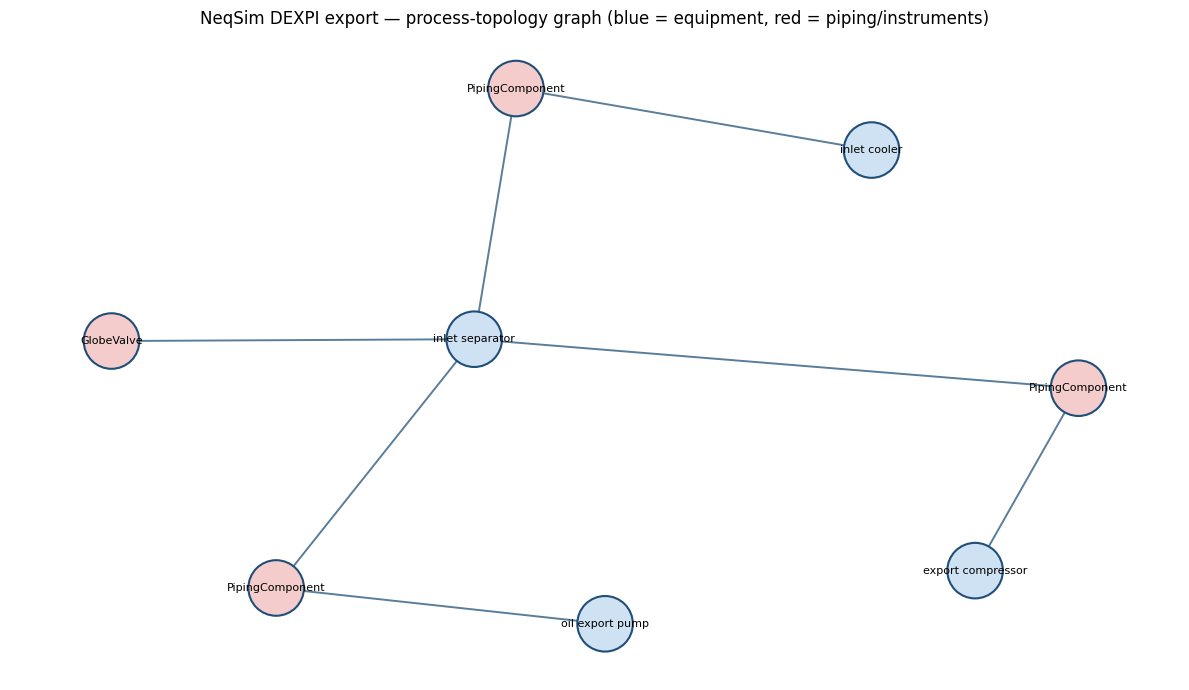

In [6]:
# Load the NeqSim-exported Proteus file and build a process-topology graph.
import pathlib
import xml.etree.ElementTree as ET

# pyDEXPI ships its SVG renderer only on the GitHub build. If the install cell could not
# reach GitHub (offline / firewall), skip this section gracefully instead of crashing.
try:
    import networkx as nx
    import matplotlib.pyplot as plt
    from pydexpi.loaders import ProteusSerializer
    from pydexpi.loaders.graph_loader import GraphLoader, GraphAbstractor
    _PYDEXPI_OK = True
except ImportError as exc:
    _PYDEXPI_OK = False
    print('pyDEXPI not available (', type(exc).__name__, '-', exc, ')')
    print('Skipping the pyDEXPI topology graph. Re-run the install cell with network access')
    print('to render genuine ISA symbols; the DEXPI XML itself was already exported above.')


def strip_namespaces(xml_path):
    """NeqSim writes a default xmlns, but pyDEXPI's Proteus parser uses
    unqualified tag lookups. Strip namespaces into a sibling *.clean.xml so the
    parser accepts the file (otherwise it reports a missing PlantInformation tag)."""
    xml_path = pathlib.Path(xml_path)
    root = ET.fromstring(xml_path.read_text(encoding='utf-8'))
    for el in root.iter():
        if isinstance(el.tag, str) and '}' in el.tag:
            el.tag = el.tag.split('}', 1)[1]
        for key in list(el.attrib):
            if '}' in key:
                el.attrib[key.split('}', 1)[1]] = el.attrib.pop(key)
    clean = xml_path.with_suffix('.clean.xml')
    ET.ElementTree(root).write(clean, encoding='utf-8', xml_declaration=True)
    return clean


if _PYDEXPI_OK:
    clean_path = strip_namespaces(dexpi_path)

    # Load the cleaned Proteus file into a pyDEXPI model.
    dexpi_model = ProteusSerializer().load(clean_path.parent, clean_path.name)

    # Full plant graph (every DEXPI instance is a node), then abstract to a process topology.
    plant_graph = GraphLoader().parse_dexpi_to_graph(dexpi_model)
    graph = GraphAbstractor.build_conceptual_graph(plant_graph)

    print('DEXPI model loaded from', dexpi_path.name)
    print(f'  Full plant graph : {plant_graph.number_of_nodes()} nodes, '
          f'{plant_graph.number_of_edges()} edges')
    print(f'  Conceptual graph : {graph.number_of_nodes()} nodes, '
          f'{graph.number_of_edges()} edges')

    def node_label(data):
        """Equipment nodes carry a tagName; piping/instrument nodes show their DEXPI class."""
        if data.get('tagName'):
            return str(data['tagName'])
        return str(data.get('label', '')).split(':')[0]

    labels = {n: node_label(d) for n, d in graph.nodes(data=True)}
    node_colors = ['#cfe2f3' if d.get('tagName') else '#f4cccc'
                   for _, d in graph.nodes(data=True)]

    fig, ax = plt.subplots(figsize=(12, 7))
    pos = nx.spring_layout(graph, seed=42, k=1.6)
    nx.draw_networkx_edges(graph, pos, ax=ax, edge_color='#5a7d9a',
                           arrows=True, arrowsize=14, width=1.4)
    nx.draw_networkx_nodes(graph, pos, ax=ax, node_color=node_colors,
                           edgecolors='#1f4e79', node_size=1600, linewidths=1.5)
    nx.draw_networkx_labels(graph, pos, labels=labels, ax=ax, font_size=8)
    ax.set_title('NeqSim DEXPI export — process-topology graph '
                 '(blue = equipment, red = piping/instruments)', fontsize=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


Wrote genuine-symbol P&ID: pfd_output\gas_train.pid.svg ( 40930 bytes )


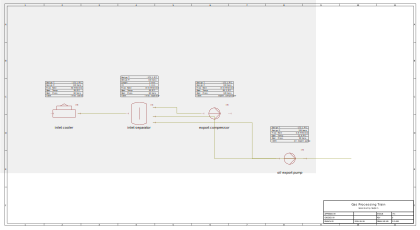

Also wrote PNG: pfd_output\gas_train.pid.png


In [10]:
# Render genuine ISA-5.1 P&ID symbols from the NeqSim DEXPI export.
if not _PYDEXPI_OK:
    print('pyDEXPI not installed — skipping genuine-symbol render.')
    print('The DEXPI XML is valid and can be opened in any DEXPI-aware P&ID tool.')
else:
    from pydexpi.loaders.svg_loader import DrawDiagram
    from IPython.display import SVG, display

    svg_path = out_dir / 'gas_train.pid.svg'

    # DrawDiagram converts the DEXPI symbol graphics (PolyLines, Circles, TrimmedCurves,
    # Presentation styling) into a real P&ID. pretty=True scales to A3 with thin line widths.
    drawer = DrawDiagram(dexpi_model.diagram, padding=5.0, pretty=True)
    drawer.save_svg(svg_path.stem, str(out_dir))   # save_svg(object_name, directory)

    print('Wrote genuine-symbol P&ID:', svg_path, '(', svg_path.stat().st_size, 'bytes )')

    # Show the vector SVG inline (best quality — true ISA symbols).
    display(SVG(filename=str(svg_path)))

    # Also rasterise to PNG for reports / environments that don't render inline SVG.
    try:
        from svglib.svglib import svg2rlg
        from reportlab.graphics import renderPM
        png_path = svg_path.with_suffix('.png')
        renderPM.drawToFile(svg2rlg(str(svg_path)), str(png_path), fmt='PNG', dpi=150)
        print('Also wrote PNG:', png_path)
    except Exception as exc:
        print('PNG rasterisation skipped (', type(exc).__name__, '-', exc, ')')


## 10. New equipment symbols (Filter, Tank) and improved pipe routing

NeqSim's DEXPI catalogue now includes dedicated ISO 10628 stencils for a **Filter** (inlet
coalescer / gas filter) and a **storage Tank** (oil surge drum), in addition to the separators,
compressors, pumps, coolers and valves used above.

Two rendering improvements show up on multi-branch diagrams:

- **Dedicated symbols** instead of a generic box — the filter and tank are immediately
  recognisable on the P&ID.
- **Tighter orthogonal routing** — each branch's vertical riser is placed a short fixed
  distance *before* its target column rather than at the segment midpoint. On a three-phase
  separator (gas / oil / water leaving to three different downstream columns) this keeps the long
  horizontal runs on the source line and gives each branch its own riser channel, which
  **reduces line crossings** compared with midpoint risers.

Below we add a **gas filter upstream** of the separator and an **oil surge tank** downstream of
the oil pump, then re-export to DEXPI so the new symbols appear in the genuine-symbol render.


In [8]:
# Build an extended train that uses the new Filter and Tank symbols.
Filter = jneqsim.process.equipment.filter.Filter
Tank = jneqsim.process.equipment.tank.Tank

fluid2 = SystemSrkEos(273.15 + 60.0, 60.0)
for comp, frac in [('nitrogen', 0.01), ('CO2', 0.02), ('methane', 0.80),
                   ('ethane', 0.06), ('propane', 0.04), ('n-butane', 0.02),
                   ('n-pentane', 0.01), ('n-hexane', 0.01), ('water', 0.03)]:
    fluid2.addComponent(comp, frac)
fluid2.setMixingRule('classic')
fluid2.setMultiPhaseCheck(True)

feed2 = Stream('well stream', fluid2)
feed2.setFlowRate(50.0, 'MSm3/day')
feed2.setTemperature(60.0, 'C')
feed2.setPressure(60.0, 'bara')

# NEW: inlet gas filter upstream of the cooler/separator.
inlet_filter = Filter('inlet gas filter', feed2)

cooler2 = Cooler('inlet cooler', inlet_filter.getOutletStream())
cooler2.setOutTemperature(30.0, 'C')

separator2 = ThreePhaseSeparator('inlet separator', cooler2.getOutletStream())

export_compressor2 = Compressor('export compressor', separator2.getGasOutStream())
export_compressor2.setOutletPressure(120.0, 'bara')

oil_pump2 = Pump('oil export pump', separator2.getOilOutStream())
oil_pump2.setOutletPressure(90.0, 'bara')

# NEW: oil surge tank downstream of the oil pump.
oil_surge_tank = Tank('oil surge drum', oil_pump2.getOutletStream())

water_valve2 = ThrottlingValve('water letdown valve', separator2.getWaterOutStream())
water_valve2.setOutletPressure(5.0, 'bara')

process2 = ProcessSystem('Gas Processing Train (with filter + tank)')
for unit in [feed2, inlet_filter, cooler2, separator2,
             export_compressor2, oil_pump2, oil_surge_tank, water_valve2]:
    process2.add(unit)
process2.run()
print('Extended process converged with', process2.size(), 'units '
      '(now including a Filter and a Tank).')

# Re-export to DEXPI so the new Filter/Tank symbols appear in the genuine-symbol render.
dexpi_path2 = out_dir / 'gas_train_filter_tank.dexpi.xml'
DexpiDiagramBridge.exportToDexpi(process2, JPaths.get(str(dexpi_path2)))
print('Wrote DEXPI P&ID with new symbols:', dexpi_path2,
      '(', dexpi_path2.stat().st_size, 'bytes )')


Extended process converged with 8 units (now including a Filter and a Tank).
Wrote DEXPI P&ID with new symbols: pfd_output\gas_train_filter_tank.dexpi.xml ( 168462 bytes )


Wrote genuine-symbol P&ID with Filter + Tank: pfd_output\gas_train_filter_tank.pid.svg ( 51525 bytes )


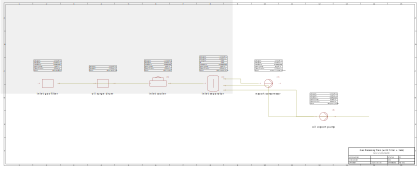

In [12]:
# Render the extended train (with Filter + Tank) using genuine ISA symbols, if pyDEXPI is present.
if not _PYDEXPI_OK:
    print('pyDEXPI not installed — skipping genuine-symbol render of the extended train.')
    print('Open', dexpi_path2.name, 'in any DEXPI-aware P&ID tool to see the Filter and Tank.')
else:
    from pydexpi.loaders.svg_loader import DrawDiagram
    from IPython.display import SVG, display

    clean_path2 = strip_namespaces(dexpi_path2)
    dexpi_model2 = ProteusSerializer().load(clean_path2.parent, clean_path2.name)

    svg_path2 = out_dir / 'gas_train_filter_tank.pid.svg'
    drawer2 = DrawDiagram(dexpi_model2.diagram, padding=5.0, pretty=True)
    drawer2.save_svg(svg_path2.stem, str(out_dir))
    print('Wrote genuine-symbol P&ID with Filter + Tank:', svg_path2,
          '(', svg_path2.stat().st_size, 'bytes )')
    display(SVG(filename=str(svg_path2)))


## 11. Reusable one-call helper — `render_dexpi_pid(process, name)`

The two render sections above repeat the same three steps: export to DEXPI, make the file
pyDEXPI-readable, then draw genuine ISA symbols. The helper below wraps all of that into a single
reusable function so any `ProcessSystem` can be turned into a P&ID in one call.

Two things make it simpler than the inline code:

- It uses **`DexpiDiagramBridge.exportForPyDexpi(...)`**, a writer variant that **omits the default
  XML namespace**, so the manual `strip_namespaces` workaround is no longer needed — the file loads
  straight into pyDEXPI's Proteus parser.
- It is **guarded by `_PYDEXPI_OK`**, so it degrades gracefully (writes the DEXPI XML and returns
  the path) when pyDEXPI is not installed, instead of crashing.


Wrote DEXPI P&ID: pfd_output\gas_train_helper.dexpi.xml ( 168275 bytes )
Wrote genuine-symbol P&ID: pfd_output\gas_train_helper.pid.svg ( 50573 bytes )


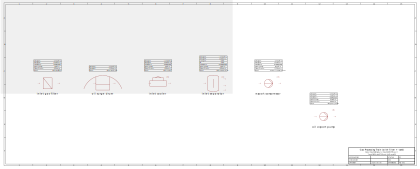

Also wrote PNG: pfd_output\gas_train_helper.pid.png
Artifacts: {'dexpi': 'pfd_output\\gas_train_helper.dexpi.xml', 'svg': 'pfd_output\\gas_train_helper.pid.svg', 'png': 'pfd_output\\gas_train_helper.pid.png'}


In [9]:
def render_dexpi_pid(process, name, out_dir=out_dir, padding=5.0, pretty=True, show=True):
    """Export a NeqSim ProcessSystem to DEXPI and render genuine ISA-5.1 P&ID symbols.

    Parameters
    ----------
    process : neqsim ProcessSystem
        A (typically already-run) process system to draw.
    name : str
        Base file name (no extension); outputs ``<name>.dexpi.xml`` and ``<name>.pid.svg``.
    out_dir : pathlib.Path
        Directory for the generated files.
    padding, pretty : float, bool
        Passed through to ``DrawDiagram`` (A3 scaling / thin lines when ``pretty``).
    show : bool
        Display the SVG inline when running interactively.

    Returns
    -------
    dict
        Paths of the artifacts written: ``{'dexpi': Path, 'svg': Path|None, 'png': Path|None}``.
    """
    out_dir = pathlib.Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    dexpi_file = out_dir / f'{name}.dexpi.xml'

    # exportForPyDexpi omits the default xmlns, so pyDEXPI can read the file directly —
    # no separate strip_namespaces() step needed.
    DexpiDiagramBridge.exportForPyDexpi(process, JPaths.get(str(dexpi_file)))
    result = {'dexpi': dexpi_file, 'svg': None, 'png': None}
    print('Wrote DEXPI P&ID:', dexpi_file, '(', dexpi_file.stat().st_size, 'bytes )')

    if not _PYDEXPI_OK:
        print('pyDEXPI not installed — DEXPI XML written; open it in any DEXPI-aware P&ID tool.')
        return result

    from pydexpi.loaders.svg_loader import DrawDiagram
    from IPython.display import SVG, display

    model = ProteusSerializer().load(dexpi_file.parent, dexpi_file.name)
    svg_file = out_dir / f'{name}.pid.svg'
    DrawDiagram(model.diagram, padding=padding, pretty=pretty).save_svg(svg_file.stem, str(out_dir))
    result['svg'] = svg_file
    print('Wrote genuine-symbol P&ID:', svg_file, '(', svg_file.stat().st_size, 'bytes )')
    if show:
        display(SVG(filename=str(svg_file)))

    try:
        from svglib.svglib import svg2rlg
        from reportlab.graphics import renderPM
        png_file = svg_file.with_suffix('.png')
        renderPM.drawToFile(svg2rlg(str(svg_file)), str(png_file), fmt='PNG', dpi=150)
        result['png'] = png_file
        print('Also wrote PNG:', png_file)
    except Exception as exc:
        print('PNG rasterisation skipped (', type(exc).__name__, '-', exc, ')')
    return result


# One-call demo: render the extended (filter + tank) train with the reusable helper.
artifacts = render_dexpi_pid(process2, 'gas_train_helper')
print('Artifacts:', {k: (str(v) if v else None) for k, v in artifacts.items()})


## 12. The most compact recipe — a P&ID figure in 4 lines

Once `process` is built and pyDEXPI is installed, a genuine-symbol P&ID figure is just four
working lines. `exportForPyDexpi` writes a namespace-free DEXPI file, `ProteusSerializer().load`
reads it, and `DrawDiagram(...).save_svg(...)` renders the ISA-5.1 symbols — no namespace
stripping and no helper needed.

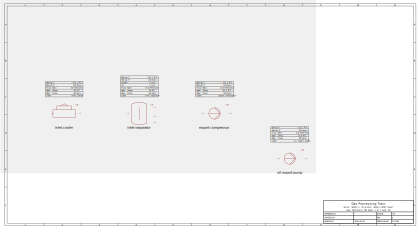

In [7]:
# ── Most compact DEXPI P&ID figure: export → load → draw → display (4 working lines) ──
from pydexpi.loaders.svg_loader import DrawDiagram
from IPython.display import SVG, display

DexpiDiagramBridge.exportForPyDexpi(process, JPaths.get(str(out_dir / 'compact.dexpi.xml')))
model = ProteusSerializer().load(out_dir, 'compact.dexpi.xml')
DrawDiagram(model.diagram, padding=5.0, pretty=True).save_svg('compact', str(out_dir))
display(SVG(filename=str(out_dir / 'compact.svg')))

## Summary

| Goal | Use |
|------|-----|
| Quick topology check | `process.toDOT()` |
| Clean teaching / overview diagram | `createDiagramExporter().setDetailLevel(CONCEPTUAL)` |
| Full engineering PFD | `createDiagramExporter().setDetailLevel(ENGINEERING)` |
| Specific simulator look | `.setDiagramStyle(HYSYS / ASPEN_PLUS / PROII / NEQSIM)` |
| Image files for reports | `.exportSVG(path)` / `.exportPNG(path)` / `.exportPDF(path)` |
| **Real ISA/ISO P&ID symbols (exchange)** | `DexpiDiagramBridge.exportToDexpi(process, path)` → open in a P&ID tool |
| **pyDEXPI-ready DEXPI (no namespace strip)** | `DexpiDiagramBridge.exportForPyDexpi(process, path)` |
| **Genuine ISA symbols rendered locally (free)** | `pydexpi` (GitHub master) → `svg_loader.DrawDiagram(model.diagram).save_svg(...)` |
| **Most compact P&ID figure (4 lines)** | `exportForPyDexpi` → `ProteusSerializer().load(...)` → `DrawDiagram(...).save_svg(...)` → `display(SVG(...))` |
| **One-call P&ID render helper** | `render_dexpi_pid(process, name)` (export + draw + PNG, guarded by `_PYDEXPI_OK`) |
| **Process-topology graph locally (free)** | `pydexpi` → `GraphLoader` + `GraphAbstractor.build_conceptual_graph(...)` |

For multi-area plant models built as a `ProcessModel`, use `plant.toDOT()` for a plant-wide
view with one cluster per area, or `plant.exportAreaDOT(dir)` to write one readable diagram per
process area.

> **Why DEXPI for real symbols?** Graphviz only has built-in shapes that *approximate* P&ID
> symbols. DEXPI (Proteus XML) is the industry exchange format — NeqSim supplies the equipment,
> tags, connectivity **and the symbol graphics**, so `pydexpi.svg_loader` (or any DEXPI-aware
> editor) renders genuine ISA-5.1 stencils.